<a href="https://colab.research.google.com/github/MariiaOsokina/LLM_Architecture---Nebius-hometask/blob/main/Copy_of_LLM_Architectures%2C_hometask_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [108]:
!pip install datasets

In [109]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

Repo card metadata block was not found. Setting CardData to empty.


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [110]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



In [111]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [112]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [113]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [114]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch**

In [115]:

"""In the context of a machine learning Loss Function, the return value is a single number (a scalar)
  that summarizes the "total unhappiness" of the model across the entire batch of reviews."""
# clamp y_pred for numerical stability

# Compute binary log-loss remmber that the loss should provide a scalar value for the backwards to work

def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute the binary cross-entropy loss for a logistic regression model.
    """
    epsilon = 1e-15

    # 1. Clamp y_pred for numerical stability
    # This prevents y_pred from being exactly 0 or 1, which makes log() explode
    y_pred = torch.clamp(y_pred, epsilon, 1.0 - epsilon)

    # 2. Compute binary log-loss
    # Formula: -(y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred))
    term_0 = y_true * torch.log(y_pred)
    term_1 = (1 - y_true) * torch.log(1 - y_pred)

    # We take the negative mean to get a single SCALAR value
    loss = -torch.mean(term_0 + term_1)

    return loss

####**Task 1.1. - Implement Logistic Regression in PyTorch (2 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [116]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros(n_features, 1)

        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().reshape(n_features, 1)

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        # Wrap weights and bias using nn.Parameter
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))


    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        """MO:In Python, there is a special "magic method" called __call__.
        If a class has this method, you can treat the object like a function.

      Because your LogisticRegression inherits from nn.Module,
      it comes pre-installed with a __call__ method
      that looks roughly like this inside the PyTorch source code"""

        logits = x @ self.w + self.b
        probs = 1/(1 + torch.exp(-logits))

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """
        """MO: needed for eval"""

        probs = self.forward(x)
        preds = (probs >=0.5).float()

        return preds

####**Task 1.2 - Train Logistic Regression with SGD Using Your Previous Implementations (1 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use:

1. your LogisticRegression class from Task 1.2
2. your binary_cross_entropy_loss function from Task 1.1

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [117]:
def compute_f1(y_hat, y_true):
    # Ensure they are flat vectors
    y_hat = y_hat.view(-1)
    y_true = y_true.view(-1)

    tp = ((y_hat == 1) & (y_true == 1)).float().sum()
    fp = ((y_hat == 1) & (y_true == 0)).float().sum()
    fn = ((y_hat == 0) & (y_true == 1)).float().sum()

    precision = tp / (tp + fp + 1e-7) # 1e-7 prevents division by zero
    recall = tp / (tp + fn + 1e-7)

    f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
    return f1.item()

In [118]:
import torch

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty='none',          # For Task 1.5 : options: 'none', 'l1', 'l2'
    reg_lambda=0.0,          # For Task 1.5
    metric='accuracy',
    print_metrics=False
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """


    # 1. Convert data to tensors

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    """MO: .view(-1,1) Shape (2D)
    """

    n_samples, n_features = X_train_tensor.shape


    # 2. Initialize model

    model = LogisticRegression(n_features=n_features, init=init)


    # 3. Create optimizer

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)


    # 4. Create logs

    history = []      # save w, b after each batch update
    epoch_log = []    # save epoch-level loss and metrics


    # 5. Training loop

    for epoch in range(epochs):
        # 1. Shuffle the training data
        perm = torch.randperm(n_samples)
        #The reviews, rearranged
        X_train_epoch = X_train_tensor[perm]
        #The labels, rearranged identically to stay matched with their reviews
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            # 2. Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # 3. Forward pass
            y_pred = model(X_batch)


            # 4. Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # 5. Add regularization if needed
            # penalty == 'l1'  -> reg_lambda * ||w||_1
            # penalty == 'l2'  -> reg_lambda * ||w||_2^2
            # penalty == 'none' -> no regularization
            if penalty == 'l1':
                reg_term = reg_lambda * torch.norm(model.w, p=1)
            elif penalty == 'l2':
                reg_term = reg_lambda * torch.norm(model.w, p=2)**2
            else:
                reg_term = 0.0
            loss = data_loss + reg_term

            # 6. Backward pass and optimization step
            optimizer.zero_grad()  # Clear old gradients
            loss.backward()        # Calculate new gradients (slopes)
            optimizer.step()       # Update w and b weights

            # 7. Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })

        """MO: detach() It "detaches" it from the history of calculations.
        clone() creates a brand new, independent copy"""

        # 8. Epoch-level evaluation

        with torch.no_grad(): # Disable gradient tracking to save memory/speed

            # 8.1. Compute probabilities on full train/val sets
            # We use the whole dataset now, not just a batch
            y_pred_train = model(X_train_tensor)
            y_pred_val = model(X_val_tensor)

            # 8.2. Compute NON-regularized train loss and val loss
            # Use your BCE function (validation should never include penalty)
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # 8.3. Convert probabilities to binary predictions (0 or 1)
            y_hat_train = model.predict(X_train_tensor)
            y_hat_val = model.predict(X_val_tensor)

            # 8.4. Compute evaluation metric (e.g., Accuracy)
            if metric == 'f1':
                # You would use a custom F1 function or sklearn here
                # For this snippet, let's assume a simple accuracy calculation
                train_metric = compute_f1(y_hat_train, y_train_tensor)
                val_metric = compute_f1(y_hat_val, y_val_tensor)
            else:
                # Default Accuracy: (Matches / Total)
                train_metric = (y_hat_train == y_train_tensor).float().mean().item()
                val_metric = (y_hat_val == y_val_tensor).float().mean().item()

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log

MO comment:** What is the F1 Metric?**

While Accuracy just counts how many times you were "right," the F1 Score cares about the balance between two specific things: Precision and Recall.

**Precision** (The "Quality" Score): Of all the reviews the model claimed were positive, how many actually were? (Avoids False Positives).

**Recall** (The "Quantity" Score): Of all the actual positive reviews that exist, how many did the model manage to find? (Avoids False Negatives).

The F1 Score is the Harmonic Mean of these two. We use the harmonic mean instead of a simple average because it heavily penalizes "one-sided" models. If your Precision is 1.0 but your Recall is 0.0, your average is 0.5, but your F1 is 0.2.


**The Math behind F1**

To calculate F1, we first need to find:

TP (True Positives): Model said 1, Truth was 1.

FP (False Positives): Model said 1, Truth was 0.FN (False Negatives): Model said 0, Truth was 1.

The formulas are:$$\text{Precision} = \frac{TP}{TP + FP}$$$$\text{Recall} = \frac{TP}{TP + FN}$$$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

####**Task 1.3 - Experiments (2 points)**



```
# This is formatted as code
```




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Hyperparameter search space
lrs = [0.01, 0.03, 0.1, 0.3, 1.0, 2.0] #2.0 added for seeing the boundary values
batch_sizes = [50, 100, 200]

#epochs = 10
epochs = 20

metric = 'f1'
results = []

for bs in batch_sizes:
    for lr in lrs:
        print(f"Training: LR={lr}, Batch Size={bs}...")

        # Run the training function
        _, _, _, epoch_log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=lr, epochs=epochs, batch_size=bs, metric=metric, print_metrics=False
        )

        # Grab the last epoch's stats
        final_stats = epoch_log[-1]
        results.append({
            'Learning Rate': lr,
            'Batch Size': bs,
            'Train metric': final_stats['train_metric'],
            'Val metric': final_stats['val_metric'],
            'Val Loss': final_stats['val_loss'],
            'Metric_name': metric,
            'epoch_log_source': epoch_log
        })

# Convert to DataFrame for easy plotting
df_results = pd.DataFrame(results)

Training: LR=0.01, Batch Size=50...
Training: LR=0.03, Batch Size=50...
Training: LR=0.1, Batch Size=50...
Training: LR=0.3, Batch Size=50...
Training: LR=1.0, Batch Size=50...
Training: LR=2.0, Batch Size=50...
Training: LR=0.01, Batch Size=100...
Training: LR=0.03, Batch Size=100...
Training: LR=0.1, Batch Size=100...
Training: LR=0.3, Batch Size=100...
Training: LR=1.0, Batch Size=100...
Training: LR=2.0, Batch Size=100...
Training: LR=0.01, Batch Size=200...
Training: LR=0.03, Batch Size=200...
Training: LR=0.1, Batch Size=200...
Training: LR=0.3, Batch Size=200...
Training: LR=1.0, Batch Size=200...
Training: LR=2.0, Batch Size=200...


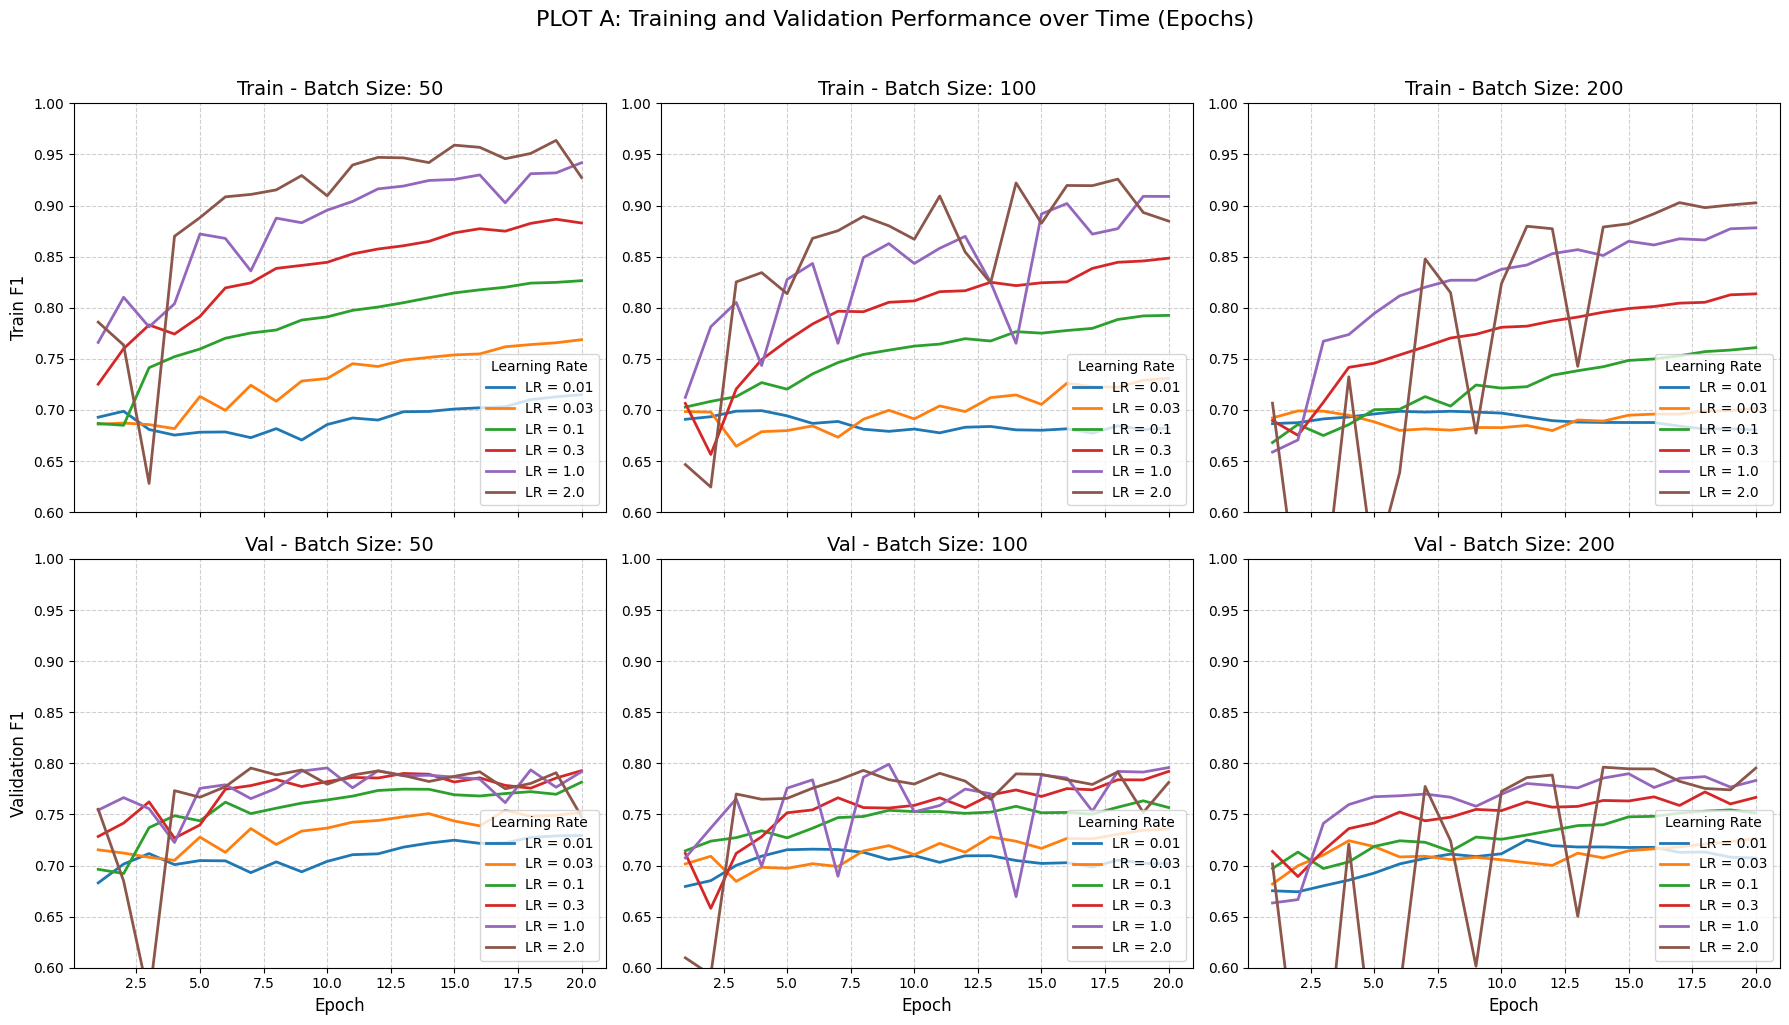

In [120]:
import matplotlib.pyplot as plt

# Create a 2x3 grid of subplots: 2 rows (Train, Val) and 3 columns (Batch Sizes)
# sharex=True makes the X-axis (epochs) shared across columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

for i, bs in enumerate(batch_sizes):
    # Filter the dataframe for the current batch size
    df_bs = df_results[df_results['Batch Size'] == bs]

    # Select the specific axes for Train (Row 0) and Val (Row 1)
    ax_train = axes[0, i]
    ax_val = axes[1, i]

    # Plot a line for each learning rate
    for lr in lrs:
        # Find the specific row for this Batch Size + LR combo
        row = df_bs[df_bs['Learning Rate'] == lr]

        if not row.empty:
            logs = row.iloc[0]['epoch_log_source']

            # Extract both metrics from the logs
            train_metrics = [log['train_metric'] for log in logs]
            val_metrics = [log['val_metric'] for log in logs]
            epochs_range = range(1, len(train_metrics) + 1)

            # Plot on the respective subplots
            ax_train.plot(epochs_range, train_metrics, label=f'LR = {lr}', linewidth=2)
            ax_val.plot(epochs_range, val_metrics, label=f'LR = {lr}', linewidth=2)

    # --- Set Y-Axis Limits (Requested 0.6 to 1) ---
    ax_train.set_ylim(0.6, 1)
    ax_val.set_ylim(0.6, 1)

    # --- Formatting Train Subplots (Top Row) ---
    ax_train.set_title(f'Train - Batch Size: {bs}', fontsize=14)
    if i == 0:
        # Use LaTeX formatting for the metric name if needed
        ax_train.set_ylabel(f'Train {metric.upper()}', fontsize=12)
    ax_train.grid(True, linestyle='--', alpha=0.6)
    ax_train.legend(title="Learning Rate", loc="lower right")

    # --- Formatting Val Subplots (Bottom Row) ---
    ax_val.set_title(f'Val - Batch Size: {bs}', fontsize=14)
    ax_val.set_xlabel('Epoch', fontsize=12)
    if i == 0:
        ax_val.set_ylabel(f'Validation {metric.upper()}', fontsize=12)
    ax_val.grid(True, linestyle='--', alpha=0.6)
    ax_val.legend(title="Learning Rate", loc="lower right")

# Add a main title to the whole figure and adjust layout
plt.suptitle('PLOT A: Training and Validation Performance over Time (Epochs)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

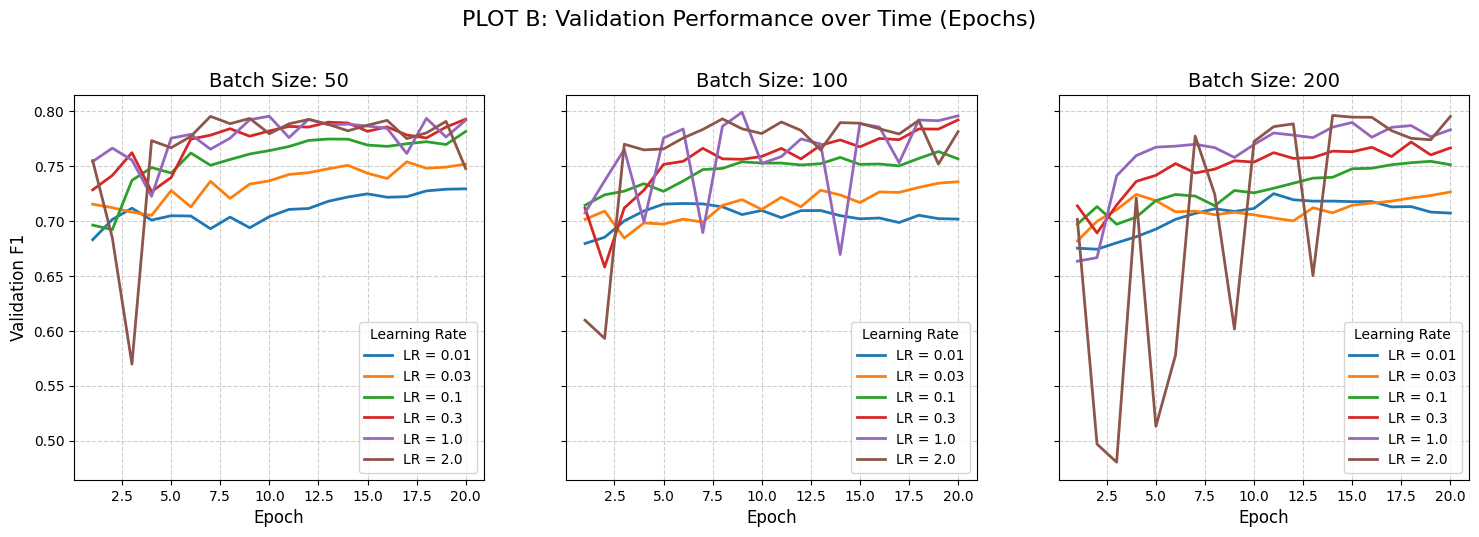

In [121]:
import matplotlib.pyplot as plt

# Set up a figure with 3 subplots in a single row
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, bs in enumerate(batch_sizes):
    ax = axes[i] # Select the current subplot

    # Filter the dataframe for the current batch size
    df_bs = df_results[df_results['Batch Size'] == bs]

    # Plot a line for each learning rate
    for lr in lrs:
        # Find the specific row for this Batch Size + LR combo
        row = df_bs[df_bs['Learning Rate'] == lr]

        if not row.empty:
            logs = row.iloc[0]['epoch_log_source']
            val_metrics = [log['val_metric'] for log in logs]
            epochs_range = range(1, len(val_metrics) + 1)

            ax.plot(epochs_range, val_metrics, label=f'LR = {lr}', linewidth=2)

    # Formatting for each subplot
    ax.set_title(f'Batch Size: {bs}', fontsize=14)
    ax.set_xlabel('Epoch', fontsize=12)
    if i == 0:
        ax.set_ylabel(f'Validation {metric.upper()}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(title="Learning Rate")

# Add a main title to the whole figure
plt.suptitle('PLOT B: Validation Performance over Time (Epochs)', fontsize=16, y=1.05)
plt.show()

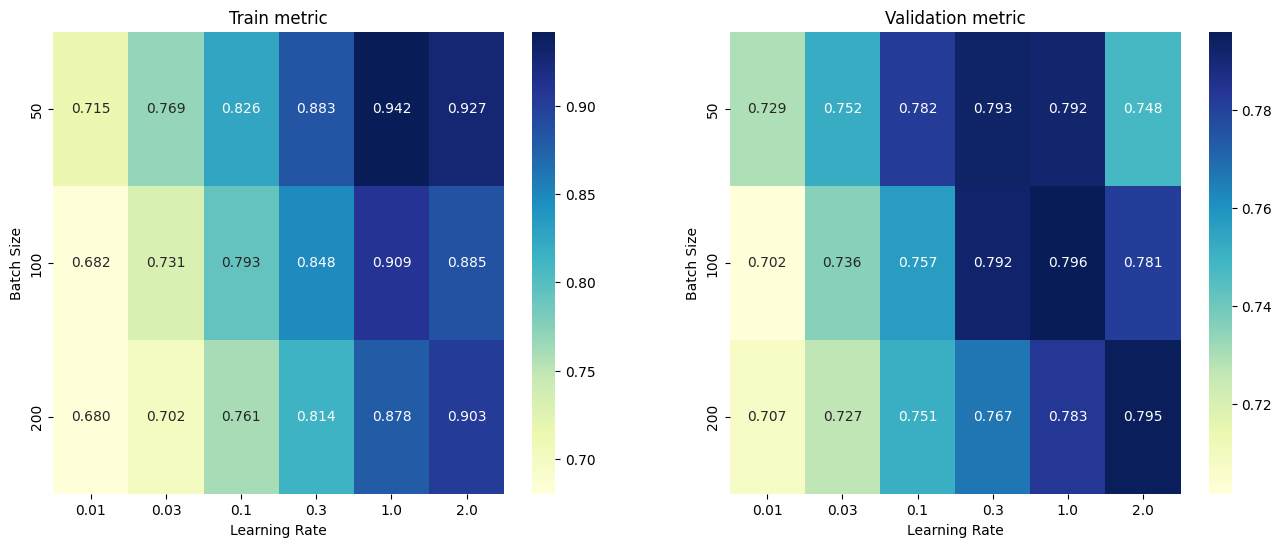

In [122]:
# heatmap
pivot_train = df_results.pivot(index="Batch Size", columns="Learning Rate", values="Train metric")
pivot_val = df_results.pivot(index="Batch Size", columns="Learning Rate", values="Val metric")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_train, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax[0])
ax[0].set_title("Train metric")

sns.heatmap(pivot_val, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax[1])
ax[1].set_title("Validation metric")

plt.show()

**TASK 1.3.- Analysis:**

**Experimental Setup**

I tested learning rates from 0.01 to 2.0 and batch sizes of 50, 100, and 200.
Note: I added LR = 2.0 to the experiments to see the "boundary values" of the model. While LR = 1.0 was the best performer, LR = 2.0 was too high.

Based on the heatmaps and Plot A, I found that the best performance came from using LR = 1.0 and Batch Size = 50 or 100.

**1. Convergence Speed**

Learning Rate: High LRs (0.3, 1.0) are like "fast steps." They reach a high F1 score much quicker (usually within the first 5 epochs). Low LRs (0.01, 0.03) are too slow and stay at the bottom of the graph because they don't have enough time to learn.

Batch Size: Smaller batches (50) learn faster because they update the weights more often in every epoch.

**2. Stability of Training**

Smooth vs. Noisy: Larger batches (200) make the training curves look smoother and more stable. Smaller batches (50) make the curves "jumpy" because each update is based on fewer examples, which creates more noise.

High LR Risk: When I increased the LR to 2.0, the training became unstable. The steps were too big, causing the model to "overshoot" the best weights and oscillate (bounce around).

**3. Final Performance (Heatmap Insights)**

The Best Zone: The heatmap shows that the "sweet spot" is LR = 1.0. If the LR is lower, the model underfits (doesn't learn enough). If the LR is higher, it becomes too chaotic.

The Gap: I noticed that with Batch Size 50, the training score is very high, but the validation score is a bit lower. Using Batch Size 100 helped close this gap, making the model generalize better to new data.

**Conclusion**

To get the best results, we need a balance. A high learning rate (1.0) is needed to reach the best performance quickly, but it works best with a medium batch size (100) to keep the training stable and avoid overfitting.

####**Task 1.4 — L1 Regularization and Sparsity (2 points)**



In this task, you will extend your implementation from Task 1.3 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

In [123]:
lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
initializations = ['zeros', 'random']

l1_results = []
metric = 'f1'
epochs = 20
#batch_size=100
#lr = 0.1

"""MO comments: based on the previous results I changed the recommmened values and chose  batch_size=50 and lr=1
because with these values the difference between train metric and val metric was bigger. It can help us to see effect of L1 regulasiation
better as the L1 goal is to fix the overfitting"""

batch_size=50
lr = 1

for init_method in initializations:
    for lam in lambdas:
        # Run training
        w_final, b_final, history, epoch_log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=lr, epochs=epochs, batch_size=batch_size,
            init=init_method, penalty='l1', reg_lambda=lam, metric=metric
        )

        # Calculate sparsity: count weights larger than 1e-7
        # num_nonzero = (np.abs(w_final) > 1e-7).sum()
        num_nonzero = (np.abs(w_final) > 1e-3).sum()

        l1_results.append({
            'init': init_method,
            'lambda': lam,
            'train_metric': epoch_log[-1]['train_metric'] if len(epoch_log) >= 1 else 0.0,
            'val_metric': epoch_log[-1]['val_metric'] if len(epoch_log) >= 1 else 0.0,
            'non_zero_count': num_nonzero,
            'epoch_log_source': epoch_log,
            'history': history,
            'metric type': metric,
            'final_w': w_final
        })

df_l1 = pd.DataFrame(l1_results)

In [47]:
# --- INITIALIZATION COMPARISON ---

# 1. Stability Check (Looking for NaNs or Divergence)
nans = df_l1[df_l1['val_metric'].isna()]
if len(nans) > 0:
    print(f"⚠️ Stability Issue: Found {len(nans)} runs that diverged (NaNs).")
    print(nans[['init', 'lambda']])
else:
    print("✅ Stability Check: All initializations remained stable.\n")

#2. Compare Validation Performance & Sparsity (Non-Zero Counts)
used_metric = df_l1['metric type'].iloc[0]

comparison_perf = df_l1.pivot(index='lambda', columns='init', values=['val_metric', 'non_zero_count']).round(4)
print(f"--- Validation Performance & Sparsity (Non-Zero Counts) Comparison (Metric: {used_metric.upper()}) ---")
print(comparison_perf)

✅ Stability Check: All initializations remained stable.

--- Validation Performance & Sparsity (Non-Zero Counts) Comparison (Metric: F1) ---
       val_metric         non_zero_count        
init       random   zeros         random   zeros
lambda                                          
0.0000     0.7943  0.7920         9979.0  9981.0
0.0001     0.7607  0.7733         6321.0  6356.0
0.0010     0.1866  0.6861         2103.0  2136.0
0.0100     0.6792  0.5661         9042.0  8989.0
0.1000     0.6753  0.4654         9809.0  9879.0


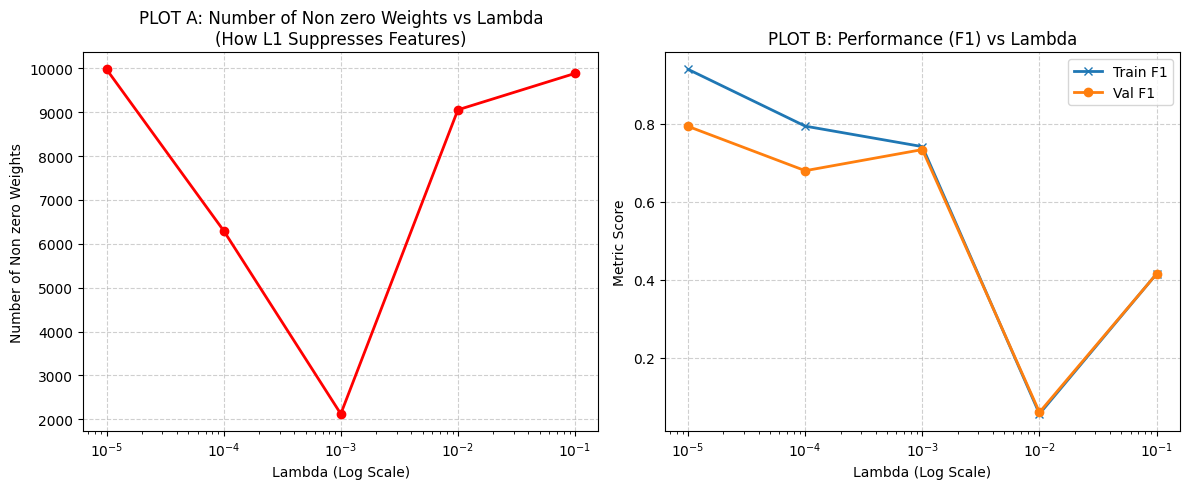

In [124]:
# --- LAMBDA STUDY & VISUALIZATION ---

# 1. Filter for 'zeros' initialization
df_study = df_l1[df_l1['init'] == 'zeros'].copy()

# 2. CRITICAL FIX: Replace 0 with 1e-5 so it plots correctly on a log scale
df_study.loc[df_study['lambda'] == 0, 'lambda'] = 1e-5

# 3. Sort by lambda to ensure lines draw smoothly from left to right
df_study = df_study.sort_values('lambda')

plt.figure(figsize=(12, 5))

# Plot A: Number of non-zero weights vs lambda
plt.subplot(1, 2, 1)
plt.plot(df_study['lambda'], df_study['non_zero_count'], marker='o', color='red', linewidth=2)
plt.xscale('log')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Number of Non zero Weights')
plt.title('PLOT A: Number of Non zero Weights vs Lambda\n(How L1 Suppresses Features)')
plt.grid(True, linestyle='--', alpha=0.6)


# Plot B: train metric vs lambda
used_metric = df_l1['metric type'].iloc[0]

plt.subplot(1, 2, 2)
plt.plot(df_study['lambda'], df_study['train_metric'], label='Train ' + used_metric.upper(), marker='x', linewidth=2)
plt.plot(df_study['lambda'], df_study['val_metric'], label='Val ' + used_metric.upper(), marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Metric Score')
plt.title(f'PLOT B: Performance ({used_metric.upper()}) vs Lambda')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

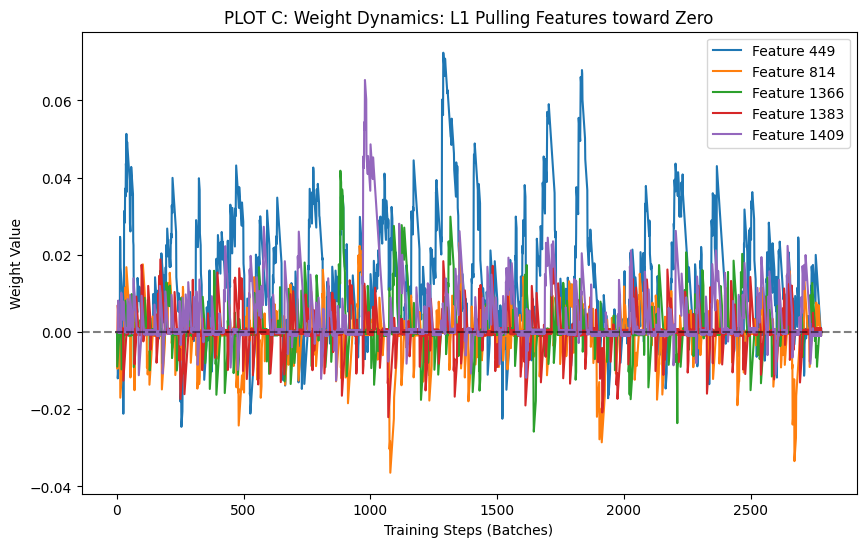

In [125]:
# WEIGHT DYNAMICS ---

# 1. Pick a run where L1 was active (e.g., lambda = 0.001)
target_run = df_l1[(df_l1['init'] == 'zeros') & (df_l1['lambda'] == 0.001)].iloc[0]
history = target_run['history']
final_w = target_run['final_w']

# 2. Identify 5 features that are very small but not exactly zero
# (These are the ones L1 is actively trying to suppress)
small_but_active_indices = np.where((np.abs(final_w) > 1e-7) & (np.abs(final_w) < 1e-5))[0][:5]

# 3. Extract the path of these weights across all training steps
# history is a list of {'w': tensor, 'b': tensor}
steps = len(history)
weight_paths = np.zeros((steps, len(small_but_active_indices)))

for i, entry in enumerate(history):
    w_at_step = entry['w'].flatten().numpy()
    weight_paths[i, :] = w_at_step[small_but_active_indices]

# 4. Plot
plt.figure(figsize=(10, 6))
for i, idx in enumerate(small_but_active_indices):
    plt.plot(weight_paths[:, i], label=f'Feature {idx}')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Training Steps (Batches)')
plt.ylabel('Weight Value')
plt.title('PLOT C: Weight Dynamics: L1 Pulling Features toward Zero')
plt.legend()
plt.show()


**TASK 1.4 - Analisys**



**Experimental Setup**

I chose 20 epochs, a batch size of 50, and a learning rate of 1.
I used these values because they created a larger gap between training and validation performance, which makes it easier to see if L1 regularization actually helps fix overfitting.

I also changed the sparsity threshold from 1e-7 to 1e-3. This is because standard SGD is "noisy" and weights often vibrate near zero without hitting it exactly. Using 1e-3 allows us to see which weights are "effectively" killed by the penalty.

**Weight Initialization (Zeros vs. Random)**

Both initialization methods were stable and did not produce NaNs.

At lambda = 0, both "zeros" and "random" performed almost identically (F1 aprox. 0.79). However, as lambda increased to 0.001, the zeros initialization remained more stable (F1 = 0.68) compared to random initialization (F1 = 0.18), which crashed much faster.


**The Effect of Lambda and Sparsity**

Feature Elimination: Plot A and the results table show that L1 successfully pushes weights toward zero. At lambda = 0.0001, the number of active weights dropped from about 10,000 to 6,300.

Performance Trade-off: While L1 created sparsity, Plot B shows that performance (F1 score) decreased as lambda got larger. This suggests that some of the "noisy" features L1 eliminated were still somewhat useful for the model's predictions.

Instability at High Lambda: Interestingly, at very high lambda (0.01 and 0.1), the non-zero count went back up to 9,000+.

In PLOT C (lambda = 0.001, zeros init) with selected 5 features we see the "L1 effect." As training progresses through the batches, the weights for these features are being dragged toward the black dashed line (zero).
Oscillation: We can see that the weights do not just move in a straight line; they "vibrate" or bounce up and down.

**Conclusion**

L1 regularization is effective for reducing the number of features, but it is difficult to tune with standard SGD and performance goes down.

For better results with L1, it would be more reasonable to try a proximal descent approach.

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (3 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

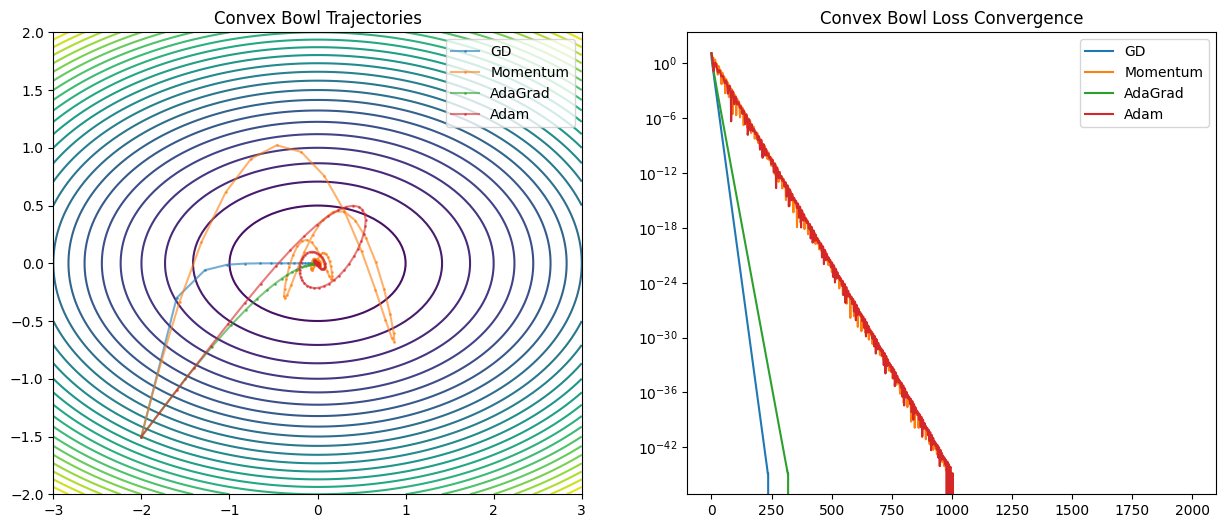

/tmp/ipykernel_12214/346301563.py:81: RuntimeWarning: invalid value encountered in log1p
  ax1.contour(X, Y, np.log1p(Z) if "Camel" in title else Z, levels=30)


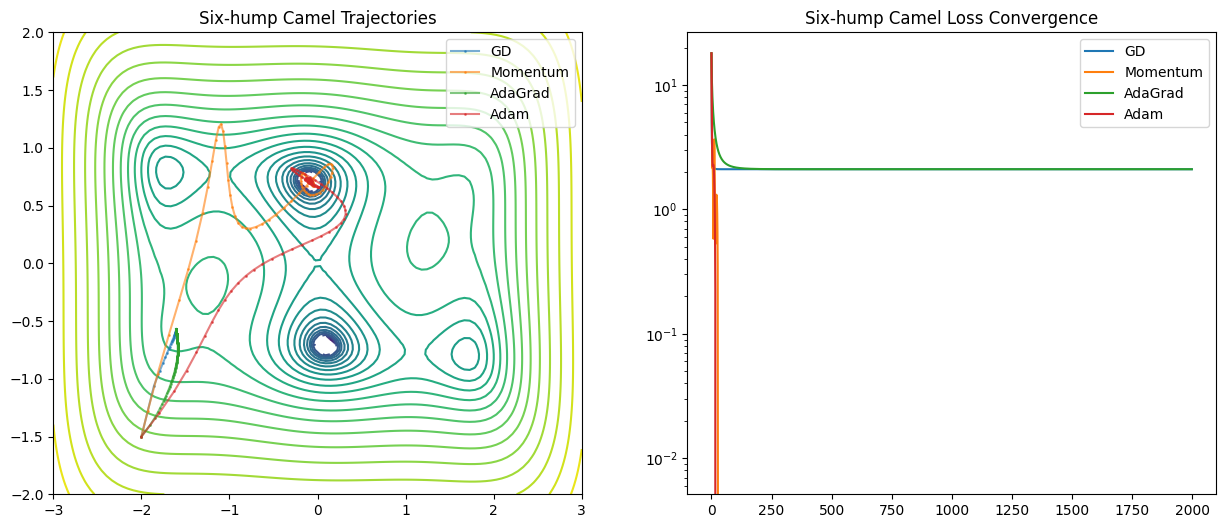

In [126]:
#code after optimization


import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Corrected Function Definitions
def bowl(theta):
    x, y = theta[..., 0], theta[..., 1]
    return x**2 + 4*y**2  # Changed 2 to 4 per prompt

def camel(theta):
    x, y = theta[..., 0], theta[..., 1]
    return (4 - 2.1 * x**2 + x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2

# 2. Refactored Optimizer Logic (DRY approach)
def optimize(f, theta0, optimizer_type="gd", n_steps=2000, lr=0.01, **kwargs):
    theta = theta0.detach().clone().to(torch.float32).requires_grad_(True)

    # State variables for specific optimizers
    v = torch.zeros_like(theta)      # For Momentum and Adam
    m = torch.zeros_like(theta)      # For Adam
    G = torch.zeros_like(theta)      # For AdaGrad

    trajectory = [theta.detach().clone()]
    values = []

    for step in range(1, n_steps + 1):
        loss = f(theta)
        values.append(loss.item())

        if theta.grad is not None:
            theta.grad.zero_()
        loss.backward()

        with torch.no_grad():
            g = theta.grad

            if optimizer_type == "gd":
                theta -= lr * g

            elif optimizer_type == "momentum":
                beta = kwargs.get('beta', 0.9)
                v = beta * v + g
                theta -= lr * v

            elif optimizer_type == "adagrad":
                eps = kwargs.get('eps', 1e-8)
                G += g**2
                theta -= lr * g / (torch.sqrt(G) + eps)

            elif optimizer_type == "adam":
                beta1 = kwargs.get('beta1', 0.9)
                beta2 = kwargs.get('beta2', 0.999)
                eps = kwargs.get('eps', 1e-8)

                m = beta1 * m + (1 - beta1) * g
                v = beta2 * v + (1 - beta2) * (g**2)
                m_hat = m / (1 - beta1**step)
                v_hat = v / (1 - beta2**step)
                theta -= lr * m_hat / (torch.sqrt(v_hat) + eps)

        trajectory.append(theta.detach().clone())

    return torch.stack(trajectory), values

# 3. Fixed Plotting Function
def plot_results(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization"):
    x = np.linspace(xlim[0], xlim[1], 100)
    y = np.linspace(ylim[0], ylim[1], 100)
    X, Y = np.meshgrid(x, y)

    # Evaluate function on grid
    grid = torch.tensor(np.stack([X, Y], axis=-1), dtype=torch.float32)
    Z = f(grid).numpy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Trajectory Plot
    ax1.contour(X, Y, np.log1p(Z) if "Camel" in title else Z, levels=30)
    for name, (traj, _) in results.items():
        ax1.plot(traj[:, 0], traj[:, 1], label=name, marker='o', markersize=1, alpha=0.6)
    ax1.set_title(f"{title} Trajectories")
    ax1.legend()

    # Loss Plot
    for name, (_, vals) in results.items():
        ax2.plot(vals, label=name)
    ax2.set_yscale('log')
    ax2.set_title(f"{title} Loss Convergence")
    ax2.legend()
    plt.show()

# Run Experiments
theta0 = torch.tensor([-2.0, -1.5])

res_bowl = {
    "GD": optimize(bowl, theta0, "gd", lr=0.1),
    "Momentum": optimize(bowl, theta0, "momentum", lr=0.02, beta=0.9),
    "AdaGrad": optimize(bowl, theta0, "adagrad", lr=0.5),
    "Adam": optimize(bowl, theta0, "adam", lr=0.2)
}

res_camel = {
    "GD": optimize(camel, theta0, "gd", lr=0.01),
    "Momentum": optimize(camel, theta0, "momentum", lr=0.005, beta=0.9),
    "AdaGrad": optimize(camel, theta0, "adagrad", lr=0.1),
    "Adam": optimize(camel, theta0, "adam", lr=0.2)
}

plot_results(bowl, res_bowl, title="Convex Bowl")
plot_results(camel, res_camel, title="Six-hump Camel")

**TASK 2 - Analysis:**

**Which optimizer performs best on the convex bowl?**

In this specific test, Gradient Descent (GD) and AdaGrad performed best. As seen in the Loss Convergence plot, they reached the bottom in about 250 steps. Because the bowl is simple, they could walk straight to the center. Adam and Momentum were actually slower (taking 1000 steps) because their learning rates were a bit too high, causing them to "spiral" and overshoot the target before settling.

**Which optimizer performs best on the Camel function?**

Adam and Momentum were far superior here. While GD and AdaGrad got trapped in the first "local minimum" they encountered, Adam and Momentum used their velocity to "jump" over the ridges of the function. While they don't guarantee finding the global optimum, their ability to escape these local traps allowed them to find a much deeper, better solution than plain GD.

**Do the same hyperparameters work equally well for both functions?**

No. The Bowl handles a high learning rate (0.1-0.2) easily. The Camel function is much more "aggressive"; using that same high rate would cause the optimizer to "catapult" out of narrow valleys or bounce wildly between walls. It requires a much smaller, conservative learning rate to stay stable.

**What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?**

Momentum: As seen in your Camel plot, it provides the "momentum" needed to push past small hills and escape local minima that stop plain GD in its tracks.

AdaGrad: It is very stable. In both plots, the green line is the smoothest, showing that it's great at handling different scales without wildly overshooting.

Adam: It is the most powerful "explorer." By combining velocity and adaptive scaling, it was able to navigate the complex Camel surface and find a much better solution than GD, even if the path looked a bit chaotic.

# Bonus. An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$